## Fig: Flip of minimum expected entropy at boundary grids due to PFA changes

Reference: `20251026_boundary_br_pm_pfa.ipynb`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from infotaxis import one_target, utils_plot_hex, hex_ops

In [2]:
path_fig = Path("../figs")

In [3]:
plot_attrs = utils_plot_hex.PLOT_ATTRS

In [4]:
pm = 0
pfa_all_br1 = [0.001, 0.05, 0.1, 0.15, 0.5]
pfa_all_br2 = [0.001, 0.035, 0.05, 0.1, 0.3]

In [5]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(ax, canvas_cube, canvas_vmap, plot_attrs, cmap):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')
    cbar.ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])

pfa=0.001
Challenging case: many similar minimum values, need careful selection.
Number of minimum choice: 61
Possible next beam sequence indices (displaying at most 10 values):
[ 7  8  9 10 11 14 15 16 17 18]
pfa=0.050
Challenging case: many similar minimum values, need careful selection.
Number of minimum choice: 61
Possible next beam sequence indices (displaying at most 10 values):
[ 7  8  9 10 11 14 15 16 17 18]
pfa=0.100
Challenging case: many similar minimum values, need careful selection.
Number of minimum choice: 61
Possible next beam sequence indices (displaying at most 10 values):
[ 7  8  9 10 11 14 15 16 17 18]
pfa=0.150
Challenging case: many similar minimum values, need careful selection.
Number of minimum choice: 06
Possible next beam sequence indices (displaying at most 10 values):
[ 0  5 40 50 85 90]
pfa=0.500
Challenging case: many similar minimum values, need careful selection.
Number of minimum choice: 06
Possible next beam sequence indices (displaying at most 10 val

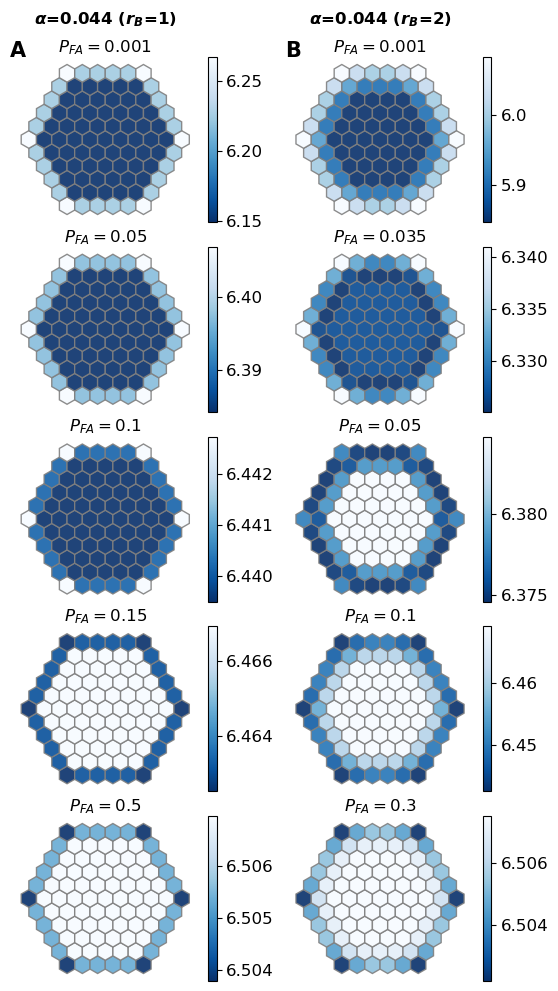

In [6]:
fig, ax_all = plt.subplots(5, 2, figsize=(6.5, 12))
fig.subplots_adjust(hspace=0.15)

# br=1
for seq, pfa in enumerate(pfa_all_br1):
    print(f"pfa={pfa:.3f}")
    # Search params
    param_echo = {
        str(1): {
            "pm_const": 0,
            "pfa_const": pfa,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
        canvas_radius=5,
        beam_radius=[1],
        target_cube=([1, -2, 1]),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=None
    )
    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha_grid = grid_in_beam / grid_in_space

    # Plot h_est map
    ax = ax_all[seq, 0]
    plot_dk_map_standalone(
        ax=ax,
        canvas_cube=oth.canvas_cube,
        canvas_vmap=oth.h_est_all[0],
        plot_attrs=utils_plot_hex.PLOT_ATTRS,
        cmap="Blues_r"
    )

    ax.set_title(rf"$P_{{FA}}={pfa}$", fontsize=12, pad=-1)
    ax.patch.set_visible(False)
    ax.axis('off')

# br=2
for seq, pfa in enumerate(pfa_all_br2):
    print(f"pfa={pfa:.3f}")
    # Search params
    param_echo = {
        str(2): {
            "pm_const": 0,
            "pfa_const": pfa,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
        canvas_radius=5,
        beam_radius=[2],
        target_cube=([1, -2, 1]),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=None
    )

    # Plot h_est map
    ax = ax_all[seq, 1]
    plot_dk_map_standalone(
        ax=ax,
        canvas_cube=oth.canvas_cube,
        canvas_vmap=oth.h_est_all[0],
        plot_attrs=utils_plot_hex.PLOT_ATTRS,
        cmap="Blues_r"
    )

    ax.set_title(rf"$P_{{FA}}={pfa}$", fontsize=12, pad=-1)
    ax.patch.set_visible(False)
    ax.axis('off')


ax_all[0, 0].text(
    0.5, 1.2, rf"$\mathbfit{{\alpha}}$={alpha_grid:.3f} ($\mathbfit{{r_B}}$=1)",
    transform=ax_all[0, 0].transAxes, fontsize=12, fontweight="bold", ha="center"
)
ax_all[0, 1].text(
    0.5, 1.2, rf"$\mathbfit{{\alpha}}$={alpha_grid:.3f} ($\mathbfit{{r_B}}$=2)",
    transform=ax_all[0, 1].transAxes, fontsize=12, fontweight="bold", ha="center"
)

ax_all[0, 0].text(-0.02, 1, "A", transform=ax_all[0, 0].transAxes, fontsize=15, fontweight="bold")
ax_all[0, 1].text(-0.02, 1, "B", transform=ax_all[0, 1].transAxes, fontsize=15, fontweight="bold")

plt.show()

fig.savefig(path_fig / "fig_S2_pfa_boundary_grids.png", dpi=300, bbox_inches="tight")
